# Deep Koopman Operator Control — Inverted Double Pendulum

The **Koopman operator** $\mathcal{K}$ is an infinite-dimensional linear operator
that acts on observable functions of the state rather than the state itself.
The central theoretical result is that *any* nonlinear dynamical system admits a
linear representation in an (infinite-dimensional) space of observables.
For control, we seek a finite-dimensional approximation learned by a neural network.

## Why Koopman for this problem?

SINDy represents the dynamics as a sparse nonlinear ODE and uses PPO (a
policy-gradient RL algorithm) to find a controller in the surrogate environment.
Koopman takes a fundamentally different path:

1. **Identify** an encoder $\varphi: \mathbb{R}^6 \to \mathbb{R}^{d_z}$ such that the
   dynamics are **linear** in the lifted space: $\varphi(x_{k+1}) \approx A\,\varphi(x_k) + B\,u_k$
2. **Design** an LQR controller analytically in the lifted space — no rollouts, no RL
3. **Iterate**: deploy LQR in the real environment to collect near-upright data,
   retrain the encoder, re-solve LQR

This eliminates surrogate exploitation entirely (no surrogate rollout ever happens)
and produces an interpretable linear model with an optimal controller.

## Koopman operator definition

For a control system $x_{k+1} = f(x_k, u_k)$, the Koopman operator $\mathcal{K}$
acts on scalar observables $g: \mathcal{X} \to \mathbb{R}$ as:

$$\mathcal{K}\,g = g \circ f \qquad \Longleftrightarrow \qquad (\mathcal{K}\,g)(x_k, u_k) = g\bigl(f(x_k, u_k)\bigr) = g(x_{k+1})$$

We seek a *vector-valued* observable $\varphi = [g_1, \dots, g_{d_z}]^\top$ such that
the image of $\mathcal{K}$ restricted to $\text{span}\{\varphi_i\}$ is **closed** —
i.e., $\varphi(x_{k+1})$ lies in the same span as $\varphi(x_k)$.
When this holds exactly, the lifted dynamics are:

$$\varphi(x_{k+1}) = A\,\varphi(x_k) + B\,u_k \qquad \text{(linear in lifted space)}$$

## Comparison with sindy-rl.ipynb

| | Dyna-SINDy-RL (`sindy-rl.ipynb`) | Deep Koopman (this notebook) |
|---|---|---|
| Dynamics model | Sparse nonlinear SINDy | Linear in learned Koopman space |
| Controller | PPO (policy-gradient RL) | LQR (discrete optimal control) |
| Iteration | Surrogate PPO + real collect | Real collect only — no surrogate |
| Exploitation risk | Mitigated by E-SINDy ensemble | **None** — no surrogate evaluation |
| Baseline | mean\_len = 854, 85% success | *evaluated below* |

## Structure

| Section | Content |
|---------|---------|
| §1 Data | 50 k bootstrap transitions |
| §2 Deep Koopman | Encoder $\varphi$, decoder $\psi$, matrices $A$, $B$ — joint training |
| §3 LQR Design | DARE in the lifted space, equilibrium cost lifting |
| §4 Iterative Collection | Deploy LQR → collect → retrain loop |
| §5 Comparison | vs Dyna-SINDy-RL baseline |

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from scipy.linalg import solve_discrete_are, LinAlgError

warnings.filterwarnings("ignore", category=UserWarning)
torch.manual_seed(0)

DEVICE = torch.device("cpu")

CWD          = pathlib.Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [CWD, *CWD.parents] if (p / "pyproject.toml").exists())
DATA_DIR     = PROJECT_ROOT / "data"
MODEL_DIR    = PROJECT_ROOT / "results" / "koopman_deep"
MODEL_DIR.mkdir(exist_ok=True, parents=True)

_env = gym.make("InvertedDoublePendulum-v5")
DT   = _env.unwrapped.dt
_env.close()

STATE_DIM    = 6
L1, L2       = 0.6, 0.6
CONV_SUCCESS = 500      # episode-length threshold — mirrors sindy-rl.ipynb
N_EVAL       = 20       # evaluation seeds
X_EQ         = np.zeros(STATE_DIM)   # upright equilibrium x* = 0

# sindy-rl.ipynb §5 baseline (Dyna-SINDy-RL, iter 6, 20 seeds)
SINDY_RL_MEAN_LEN = 853.7
SINDY_RL_MEAN_RET = 7988.57
SINDY_RL_SUCCESS  = 0.85

def obs_to_state6(obs):
    return np.array([
        obs[0],
        np.arctan2(obs[1], obs[3]),
        np.arctan2(obs[2], obs[4]),
        obs[5], obs[6], obs[7],
    ])

def tip_height(s):
    return float(L1 * np.cos(s[1]) + L2 * np.cos(s[1] + s[2]))

print(f"DT = {DT:.4f} s  |  device = {DEVICE}")
print(f"Project root: {PROJECT_ROOT}")

DT = 0.0500 s  |  device = cpu
Project root: /Users/patrick/Documents/personal/UW/ME_595


## §1  Data

We reuse the 50 000 near-upright transitions from the probe-bootstrap phase
(identical to `sindy-rl.ipynb`), giving an apples-to-apples comparison.

$$x = \bigl[\underbrace{x_\text{cart}}_{\mathbb{R}},\;
            \underbrace{\theta_1,\,\theta_2}_{\text{angles}},\;
            \underbrace{\dot{x},\,\dot{\theta}_1,\,\dot{\theta}_2}_{\text{velocities}}
     \bigr] \in \mathbb{R}^6, \qquad u \in [-1,\,1]$$

Upright equilibrium: $x^* = \mathbf{0}$, tip height $= L_1 + L_2 = 1.2\,\text{m}$.

In [4]:
# ── Load Schroeder bootstrap (sindy-rl.ipynb §1) ──────────────────────────────
# The Schroeder multi-sine sweep starts every episode near x*=0 with a small
# perturbation and applies a flat-spectrum deterministic force. Episodes are
# short (≤80 steps) but 40% of transitions land in the very-near-upright
# regime (|θ₁|,|θ₂| < 0.1 rad) vs 15% for the trackA probe bootstrap.
# More near-upright signal → encoder learns better A near the equilibrium.
SCHROEDER_PATH = DATA_DIR / "sindy_rl" / "bootstrap_schroeder.npz"
TRACKA_PATH    = DATA_DIR / "trajectories_trackA_probe_bootstrap.npz"

if SCHROEDER_PATH.exists():
    d = np.load(SCHROEDER_PATH)
    src = "Schroeder (sindy-rl.ipynb §1)"
else:
    d = np.load(TRACKA_PATH)
    src = "trackA probe (fallback)"

X_all, U_all, Xn_all = d["X"], d["U"], d["X_next"]

rng    = np.random.default_rng(42)
idx    = rng.permutation(len(X_all))
n_test = max(1, len(X_all) // 5)

X_tr,  U_tr,  Xn_tr  = X_all[idx[n_test:]], U_all[idx[n_test:]], Xn_all[idx[n_test:]]
X_te,  U_te,  Xn_te  = X_all[idx[:n_test]], U_all[idx[:n_test]], Xn_all[idx[:n_test]]

def near_upright_frac(X, thr=0.1):
    return float(np.mean((np.abs(X[:,1]) < thr) & (np.abs(X[:,2]) < thr)))

print(f"Bootstrap source : {src}")
print(f"Total transitions: {len(X_all):,}   Train: {len(X_tr):,}   Test: {len(X_te):,}")
print(f"Near-upright (|θ|<0.1 rad): {near_upright_frac(X_all):.1%}")
print(f"  (trackA probe reference: 50,000 transitions at 15.2% near-upright)")
print(f"State ranges (train):")
labels = ["x", "θ₁", "θ₂", "ẋ", "θ̇₁", "θ̇₂"]
for i, lab in enumerate(labels):
    print(f"  {lab:4s}: [{X_tr[:, i].min():.2f}, {X_tr[:, i].max():.2f}]")

Bootstrap source : Schroeder (sindy-rl.ipynb §1)
Total transitions: 2,897   Train: 2,318   Test: 579
Near-upright (|θ|<0.1 rad): 39.6%
  (trackA probe reference: 50,000 transitions at 15.2% near-upright)
State ranges (train):
  x   : [-0.47, 0.41]
  θ₁  : [-0.84, 0.78]
  θ₂  : [-1.15, 1.16]
  ẋ   : [-1.69, 1.52]
  θ̇₁ : [-4.55, 4.51]
  θ̇₂ : [-6.32, 6.31]


## §2  Deep Koopman Identification

### 2.1  Model architecture

We parameterize the finite-dimensional Koopman approximation with three components
trained jointly:

| Component | Role | Architecture |
|-----------|------|-------------|
| Encoder $\varphi_\theta: \mathbb{R}^6 \to \mathbb{R}^{d_z}$ | Lifts state to Koopman space | MLP: 6 → 64 → 64 → $d_z$, ELU |
| Decoder $\psi_\theta: \mathbb{R}^{d_z} \to \mathbb{R}^6$ | Projects back to state space | MLP: $d_z$ → 64 → 64 → 6, linear output |
| Koopman matrices $(A, B)$ | Linear dynamics in lifted space | Learnable: $A \in \mathbb{R}^{d_z \times d_z}$, $B \in \mathbb{R}^{d_z \times 1}$ |

The lifted dynamics hypothesis:

$$z_{k+1} = A\,z_k + B\,u_k, \qquad z_k \triangleq \varphi_\theta(x_k)$$

### 2.2  Training losses

All four losses act on the same set of transitions $(x_k,\, u_k,\, x_{k+1})$:

$$\mathcal{L} = \alpha\,\mathcal{L}_\text{recon} + \beta\,\mathcal{L}_\text{pred} + \gamma\,\mathcal{L}_\text{decode} + \delta\,\mathcal{L}_\text{eq}$$

**Reconstruction** — the encoder–decoder round-trip must be lossless:
$$\mathcal{L}_\text{recon} = \frac{1}{N}\sum_{k=1}^N \bigl\|\psi_\theta(\varphi_\theta(x_k)) - x_k\bigr\|^2$$

**Latent prediction** — the linear dynamics must hold in the encoded space:
$$\mathcal{L}_\text{pred} = \frac{1}{N}\sum_{k=1}^N \bigl\|\varphi_\theta(x_{k+1}) - A\,\varphi_\theta(x_k) - B\,u_k\bigr\|^2$$

**Decoded prediction** — the full round-trip $x_k \xrightarrow{\varphi} z_k \xrightarrow{A,B} z_{k+1} \xrightarrow{\psi} x_{k+1}$ must be accurate:
$$\mathcal{L}_\text{decode} = \frac{1}{N}\sum_{k=1}^N \bigl\|\psi_\theta\!\bigl(A\,\varphi_\theta(x_k) + B\,u_k\bigr) - x_{k+1}\bigr\|^2$$

**Equilibrium fixed-point** — the upright equilibrium $x^* = \mathbf{0}$ must be a fixed
point of the unforced Koopman dynamics.  Define $z^* \triangleq \varphi_\theta(x^*)$.
We require $A\,z^* = z^*$, i.e.:

$$\mathcal{L}_\text{eq} = \bigl\|A\,\varphi_\theta(x^*) - \varphi_\theta(x^*)\bigr\|^2$$

**Why $\mathcal{L}_\text{eq}$ is essential for LQR.**
Define $\delta z_k = \varphi_\theta(x_k) - z^*$.  Then:

$$\delta z_{k+1} = A\,\varphi_\theta(x_k) + B\,u_k - z^*
= A(\delta z_k + z^*) + B\,u_k - z^*
= A\,\delta z_k + \underbrace{(A\,z^* - z^*)}_{=\,0\;\text{by }\mathcal{L}_\text{eq}} + B\,u_k$$

so the deviation dynamics are the **clean linear system** $\delta z_{k+1} = A\,\delta z_k + B\,u_k$
amenable to standard DARE-based LQR.  Without $\mathcal{L}_\text{eq}$, there is an
uncontrolled offset $(A - I)z^*$ that biases every LQR step.

In [5]:
LATENT_DIM = 32
HIDDEN_DIM = 64

class KoopmanNet(nn.Module):
    """
    Deep Koopman network: encoder phi, decoder psi, linear dynamics (A, B).
    Lifted dynamics: z_{k+1} = A z_k + B u_k,  z_k = phi(x_k)
    """
    def __init__(self, state_dim=STATE_DIM, latent_dim=LATENT_DIM, hidden=HIDDEN_DIM):
        super().__init__()
        self.state_dim  = state_dim
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ELU(),
            nn.Linear(hidden, hidden),    nn.ELU(),
            nn.Linear(hidden, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden), nn.ELU(),
            nn.Linear(hidden, hidden),     nn.ELU(),
            nn.Linear(hidden, state_dim),
        )
        # A initialised near identity — encourages near-neutral dynamics early in training
        self.A = nn.Linear(latent_dim, latent_dim, bias=False)
        nn.init.eye_(self.A.weight)
        with torch.no_grad():
            self.A.weight.add_(0.01 * torch.randn_like(self.A.weight))

        self.B = nn.Linear(1, latent_dim, bias=False)
        nn.init.normal_(self.B.weight, 0.0, 0.1)

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x, u, x_next):
        """Return all quantities needed to compute the four losses."""
        z           = self.encoder(x)
        z_next_pred = self.A(z) + self.B(u)        # A z + B u
        z_next_true = self.encoder(x_next)
        x_recon     = self.decoder(z)
        x_next_pred = self.decoder(z_next_pred)
        return z, z_next_pred, z_next_true, x_recon, x_next_pred


model = KoopmanNet()
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"KoopmanNet  d_z={LATENT_DIM}  hidden={HIDDEN_DIM}  params={n_params:,}")
print(f"  encoder : {sum(p.numel() for p in model.encoder.parameters()):,}")
print(f"  decoder : {sum(p.numel() for p in model.decoder.parameters()):,}")
print(f"  A       : {model.A.weight.numel():,}")
print(f"  B       : {model.B.weight.numel():,}")

KoopmanNet  d_z=32  hidden=64  params=14,406
  encoder : 6,688
  decoder : 6,662
  A       : 1,024
  B       : 32


In [6]:
def train_koopman(model, X, U, Xn,
                  n_epochs=500, batch_size=512, lr=1e-3,
                  alpha=1.0, beta=1.0, gamma=1.0, delta_eq=10.0,
                  verbose=True):
    """
    Train Deep Koopman network.

    Loss = alpha * L_recon + beta * L_pred + gamma * L_decode + delta_eq * L_eq

      L_recon  = ||psi(phi(x)) - x||^2
      L_pred   = ||phi(x') - A phi(x) - B u||^2
      L_decode = ||psi(A phi(x) + B u) - x'||^2
      L_eq     = ||A phi(x*) - phi(x*)||^2   (equilibrium fixed-point)

    Returns list of per-epoch total losses.
    """
    opt  = optim.Adam(model.parameters(), lr=lr)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs, eta_min=lr / 20)
    F    = nn.functional

    Xt  = torch.tensor(X,  dtype=torch.float32)
    Ut  = torch.tensor(U,  dtype=torch.float32)
    Xnt = torch.tensor(Xn, dtype=torch.float32)
    x_eq = torch.zeros(1, model.state_dim)   # upright equilibrium x* = 0

    ds  = TensorDataset(Xt, Ut, Xnt)
    dl  = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)

    history = []
    for epoch in range(1, n_epochs + 1):
        model.train()
        ep_loss = 0.0
        for xb, ub, xnb in dl:
            opt.zero_grad()
            z, z_next_pred, z_next_true, x_recon, x_next_pred = model(xb, ub, xnb)

            L_recon  = F.mse_loss(x_recon,     xb)
            L_pred   = F.mse_loss(z_next_pred,  z_next_true)
            L_decode = F.mse_loss(x_next_pred,  xnb)

            z_eq   = model.encoder(x_eq)           # phi(x*)
            Az_eq  = model.A(z_eq)                 # A phi(x*)
            L_eq   = F.mse_loss(Az_eq, z_eq)       # ||A phi(x*) - phi(x*)||^2

            loss = alpha*L_recon + beta*L_pred + gamma*L_decode + delta_eq*L_eq
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            ep_loss += loss.item() * len(xb)

        sched.step()
        ep_loss /= len(Xt)
        history.append(ep_loss)

        if verbose and epoch % 100 == 0:
            model.eval()
            with torch.no_grad():
                n_v = min(2000, len(Xt))
                _, _, _, _, xp = model(Xt[:n_v], Ut[:n_v], Xnt[:n_v])
                rmse = float(torch.sqrt(F.mse_loss(xp, Xnt[:n_v])))
            print(f"  epoch {epoch:4d}  loss={ep_loss:.5f}  decode_rmse={rmse:.4f}")

    return history

Pre-training on 2,318 transitions for 500 epochs (batch=512) ...
  epoch  100  loss=0.00786  decode_rmse=0.0699
  epoch  200  loss=0.00383  decode_rmse=0.0501
  epoch  300  loss=0.00284  decode_rmse=0.0428
  epoch  400  loss=0.00244  decode_rmse=0.0399
  epoch  500  loss=0.00229  decode_rmse=0.0385


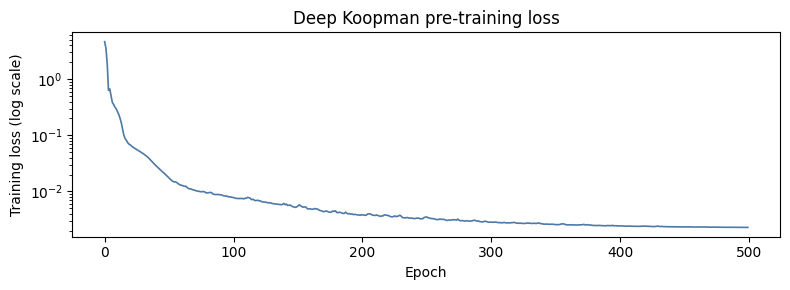

In [7]:
N_PRETRAIN = 500

# Batch size scales with dataset — avoid batches larger than 25% of training set
batch_size_pre = min(512, max(64, len(X_tr) // 4))

print(f"Pre-training on {len(X_tr):,} transitions for {N_PRETRAIN} epochs "
      f"(batch={batch_size_pre}) ...")
model = KoopmanNet()
history_pre = train_koopman(model, X_tr, U_tr, Xn_tr,
                             n_epochs=N_PRETRAIN, batch_size=batch_size_pre, verbose=True)
torch.save(model.state_dict(), MODEL_DIR / "koopman_pretrained.pt")

fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(history_pre, lw=1.2, color="#4e79a7")
ax.set_xlabel("Epoch"); ax.set_ylabel("Training loss (log scale)")
ax.set_title("Deep Koopman pre-training loss")
plt.tight_layout()
plt.savefig(MODEL_DIR / "koopman_loss.png", dpi=150)
plt.show()

Deep Koopman  one-step decode RMSE (test) : 0.037256
EDMD poly-2  (from koopman-dynamics.ipynb): 1.075969  (reference)
SINDy deg-2  (from trackA notebook)       : 1.053028  (reference)


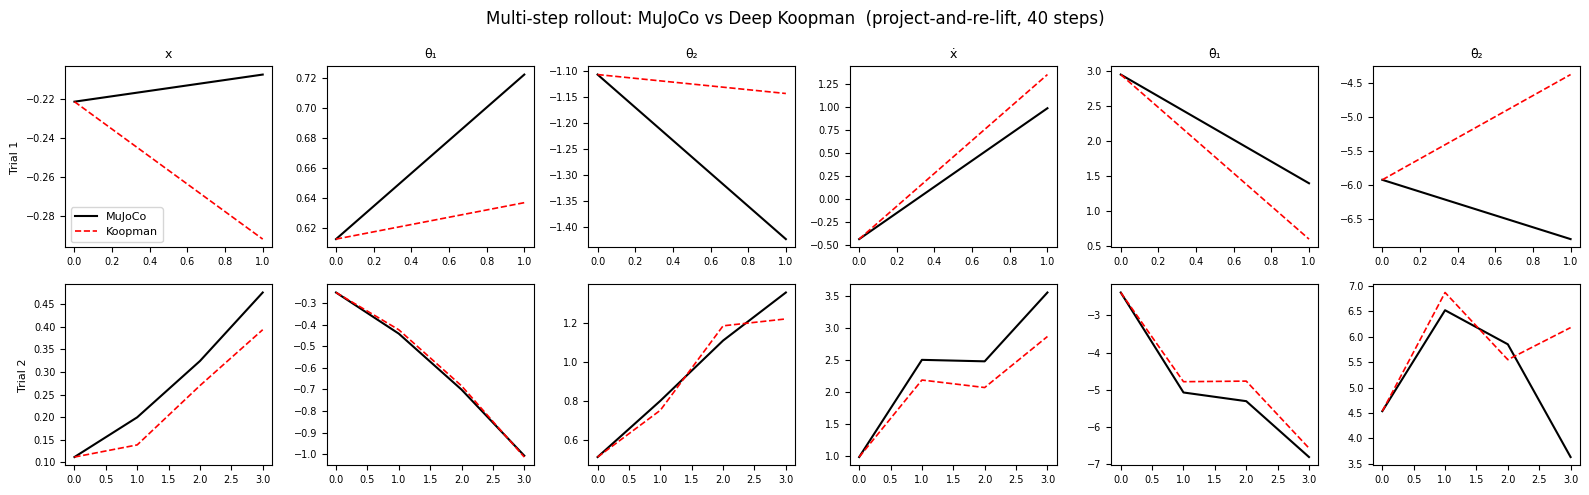

Mean rollout RMSE over 2 trials (40 steps): 0.6622


In [8]:
# ── One-step RMSE on held-out test set ────────────────────────────────────────
model.eval()
with torch.no_grad():
    Xte_t  = torch.tensor(X_te,  dtype=torch.float32)
    Ute_t  = torch.tensor(U_te,  dtype=torch.float32)
    Xnte_t = torch.tensor(Xn_te, dtype=torch.float32)
    _, _, _, _, xp_te = model(Xte_t, Ute_t, Xnte_t)
    rmse_te = float(torch.sqrt(nn.functional.mse_loss(xp_te, Xnte_t)))

print(f"Deep Koopman  one-step decode RMSE (test) : {rmse_te:.6f}")
print(f"EDMD poly-2  (from koopman-dynamics.ipynb): 1.075969  (reference)")
print(f"SINDy deg-2  (from trackA notebook)       : 1.053028  (reference)")

# ── Multi-step rollout comparison ─────────────────────────────────────────────
def rollout_koopman(model, x0, U_seq):
    """Project-and-re-lift rollout using learned encoder/decoder."""
    traj = [x0.copy()]
    x    = x0.copy()
    model.eval()
    with torch.no_grad():
        for u in U_seq:
            xt = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
            ut = torch.tensor([[u]], dtype=torch.float32)
            z  = model.encoder(xt)
            zn = model.A(z) + model.B(ut)
            x  = model.decoder(zn).squeeze().numpy()
            if not np.all(np.isfinite(x)):
                break
            traj.append(x.copy())
    return np.array(traj)

def rollout_mujoco(x0, U_seq, seed=0):
    env = gym.make("InvertedDoublePendulum-v5")
    env.reset(seed=seed)
    env.unwrapped.set_state(x0[:3], x0[3:])
    traj = [x0.copy()]
    for u in U_seq:
        obs, _, term, trunc, _ = env.step(np.array([u], dtype=np.float32))
        traj.append(obs_to_state6(obs))
        if term or trunc: break
    env.close()
    return np.array(traj)

rng_r  = np.random.default_rng(7)
N_ROLL = 40
labels = ["x", "θ₁", "θ₂", "ẋ", "θ̇₁", "θ̇₂"]
fig, axes = plt.subplots(2, STATE_DIM, figsize=(16, 5), sharex=False)
rmse_roll = []
for trial in range(2):
    ic  = X_tr[rng_r.integers(0, len(X_tr))].copy()
    U   = rng_r.uniform(-1.0, 1.0, N_ROLL)
    mj  = rollout_mujoco(ic, U)
    kp  = rollout_koopman(model, ic, U)
    n   = min(len(mj), len(kp))
    rmse_roll.append(np.sqrt(np.mean((mj[:n] - kp[:n])**2)))
    t = np.arange(n)
    for col in range(STATE_DIM):
        ax = axes[trial, col]
        ax.plot(t, mj[:n, col], "k-",  lw=1.5, label="MuJoCo" if trial==0 and col==0 else "_")
        ax.plot(t, kp[:n, col], "r--", lw=1.2, label="Koopman" if trial==0 and col==0 else "_")
        if trial == 0: ax.set_title(labels[col], fontsize=9)
        ax.tick_params(labelsize=7)
    axes[trial, 0].set_ylabel(f"Trial {trial+1}", fontsize=8)
axes[0, 0].legend(fontsize=8)
fig.suptitle(f"Multi-step rollout: MuJoCo vs Deep Koopman  (project-and-re-lift, {N_ROLL} steps)")
plt.tight_layout()
plt.savefig(MODEL_DIR / "koopman_rollout.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Mean rollout RMSE over 2 trials ({N_ROLL} steps): {np.mean(rmse_roll):.4f}")

## §3  LQR Control Design in Koopman Lifted Space

### 3.1  Deviation dynamics

Define the **lifted equilibrium** $z^* \triangleq \varphi_\theta(x^*)$ and the
**deviation** $\delta z_k = \varphi_\theta(x_k) - z^*$.
Because of the fixed-point loss enforced during training ($A z^* = z^*$), the
deviation evolves as a standard affine-free linear system:

$$\boxed{\delta z_{k+1} = A\,\delta z_k + B\,u_k}$$

The control task is to drive $\delta z_k \to 0$, which (via the decoder) drives $x_k \to x^*$.

### 3.2  Cost in lifted coordinates

We wish to penalize physical state deviations with the quadratic cost:

$$J = \sum_{k=0}^{\infty}\bigl(x_k^T Q_\text{phys}\,x_k + u_k^T R\,u_k\bigr)$$

Linearizing the decoder $\psi_\theta$ around $z^*$ via its Jacobian
$J_\psi \triangleq \left.\frac{\partial \psi_\theta}{\partial z}\right|_{z^*} \in \mathbb{R}^{6 \times d_z}$
gives $x_k \approx J_\psi\,\delta z_k$, so:

$$x_k^T Q_\text{phys}\,x_k \;\approx\; \delta z_k^T \underbrace{\bigl(J_\psi^T Q_\text{phys}\,J_\psi\bigr)}_{Q_\ell \in \mathbb{R}^{d_z \times d_z}}\,\delta z_k$$

We add a small ridge $\varepsilon I$ to ensure $Q_\ell \succ 0$ (required for detectability):

$$Q_\ell = J_\psi^T Q_\text{phys}\,J_\psi + \varepsilon\,I_{d_z}$$

The physical weights used here:

$$Q_\text{phys} = \operatorname{diag}(1, 100, 50, 0.1, 1, 0.5)$$

Angle deviations carry the highest cost; velocities moderate cost; cart position low cost.

### 3.3  Discrete algebraic Riccati equation (DARE)

The optimal cost-to-go matrix $P \succ 0$ solves:

$$P = Q_\ell + A^T P A - A^T P B\,(R + B^T P B)^{-1} B^T P A$$

A unique PD solution exists if and only if $(A, B)$ is **stabilizable** and
$(A, Q_\ell^{1/2})$ is **detectable** — conditions we verify numerically.

### 3.4  Optimal gain and control law

$$K = (R + B^T P B)^{-1} B^T P A \in \mathbb{R}^{1 \times d_z}$$

$$\boxed{u_k = -K\,\bigl(\varphi_\theta(x_k) - z^*\bigr)}$$

The closed-loop deviation system $\delta z_{k+1} = (A - BK)\,\delta z_k$ is
**asymptotically stable** iff all eigenvalues of $(A - BK)$ lie strictly inside
the unit circle, which holds when the DARE solution exists.

DARE solved  sr_ol=1.2878  sr_cl=0.9984  unstable eigenvalues=0
Closed-loop system is stable.


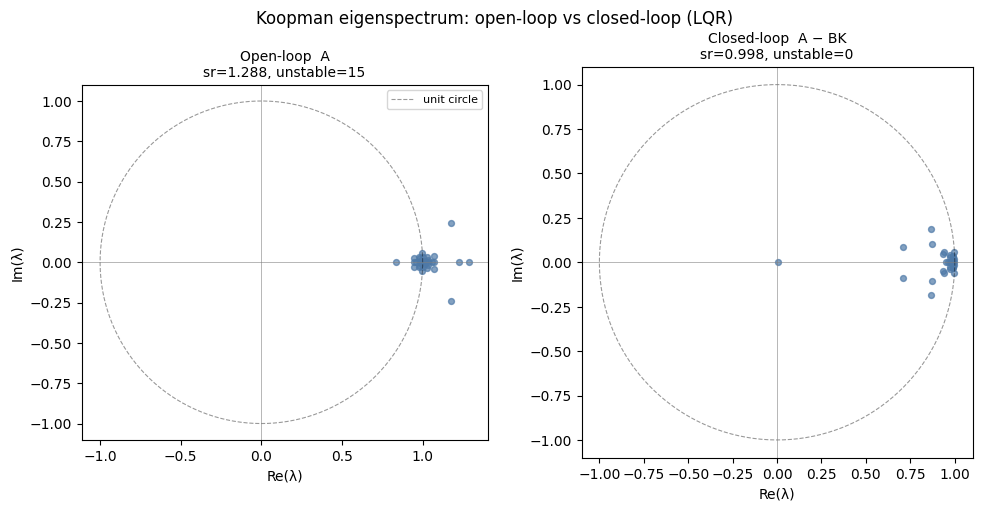

In [9]:
def decoder_jacobian(model, z_star, eps=1e-4):
    """Numerical Jacobian J_psi = d psi / d z |_{z*}  shape: (6, d_z)."""
    d_z = len(z_star)
    J   = np.zeros((STATE_DIM, d_z))
    model.eval()
    z0 = torch.tensor(z_star, dtype=torch.float32)
    with torch.no_grad():
        x0 = model.decode(z0.unsqueeze(0)).squeeze().numpy()
        for i in range(d_z):
            zp = z0.clone(); zp[i] += eps
            xp = model.decode(zp.unsqueeze(0)).squeeze().numpy()
            J[:, i] = (xp - x0) / eps
    return J


def design_lqr(model, Q_phys=None, R_ctrl=None, eps_ridge=1e-3):
    """
    Solve DARE in the Koopman lifted space.

    Returns a dict with keys: K, z_star, sr_ol, sr_cl, n_unstable, A, B, Q_l
    Raises LinAlgError if DARE fails (not stabilisable / not detectable).
    """
    if Q_phys is None:
        Q_phys = np.diag([1.0, 100.0, 50.0, 0.1, 1.0, 0.5])
    if R_ctrl is None:
        R_ctrl = np.array([[0.1]])

    model.eval()
    with torch.no_grad():
        x_eq_t = torch.zeros(1, model.state_dim)
        z_star = model.encode(x_eq_t).squeeze().numpy()   # z* = phi(x*)

    # nn.Linear(in=1, out=d_z).weight has shape (d_z, 1) — correct shape for DARE
    A_np = model.A.weight.detach().numpy()       # (d_z, d_z)
    B_np = model.B.weight.detach().numpy()       # (d_z, 1)

    J_psi = decoder_jacobian(model, z_star)      # (6, d_z)
    Q_l   = J_psi.T @ Q_phys @ J_psi + eps_ridge * np.eye(model.latent_dim)

    sr_ol = float(np.max(np.abs(np.linalg.eigvals(A_np))))

    P   = solve_discrete_are(A_np, B_np, Q_l, R_ctrl)
    K   = np.linalg.solve(R_ctrl + B_np.T @ P @ B_np, B_np.T @ P @ A_np)  # (1, d_z)

    A_cl    = A_np - B_np @ K
    eigs_cl = np.linalg.eigvals(A_cl)
    sr_cl   = float(np.max(np.abs(eigs_cl)))
    n_uns   = int(np.sum(np.abs(eigs_cl) > 1.001))

    return {"K": K, "z_star": z_star, "sr_ol": sr_ol, "sr_cl": sr_cl,
            "n_unstable": n_uns, "A": A_np, "B": B_np, "Q_l": Q_l,
            "eigs_cl": eigs_cl}


# ── Attempt DARE ───────────────────────────────────────────────────────────────
try:
    lqr0 = design_lqr(model)
    print(f"DARE solved  sr_ol={lqr0['sr_ol']:.4f}  sr_cl={lqr0['sr_cl']:.4f}  "
          f"unstable eigenvalues={lqr0['n_unstable']}")
    if lqr0["n_unstable"] == 0:
        print("Closed-loop system is stable.")
    else:
        print(f"WARNING: {lqr0['n_unstable']} closed-loop eigenvalues outside unit circle.")
except (LinAlgError, Exception) as e:
    print(f"DARE failed: {e}")
    lqr0 = None

# ── Eigenspectrum plot ─────────────────────────────────────────────────────────
if lqr0 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    theta = np.linspace(0, 2*np.pi, 300)
    for ax, eigs, title in [
        (axes[0], np.linalg.eigvals(lqr0["A"]), "Open-loop  A"),
        (axes[1], lqr0["eigs_cl"],               "Closed-loop  A − BK"),
    ]:
        ax.plot(np.cos(theta), np.sin(theta), "k--", lw=0.8, alpha=0.4, label="unit circle")
        ax.scatter(eigs.real, eigs.imag, s=18, alpha=0.7, c="#4e79a7")
        n_out = int(np.sum(np.abs(eigs) > 1.001))
        ax.set_title(f"{title}\nsr={np.max(np.abs(eigs)):.3f}, unstable={n_out}", fontsize=10)
        ax.set_aspect("equal")
        ax.axhline(0, color="gray", lw=0.4); ax.axvline(0, color="gray", lw=0.4)
        ax.set_xlabel("Re(λ)"); ax.set_ylabel("Im(λ)")
    axes[0].legend(fontsize=8)
    fig.suptitle("Koopman eigenspectrum: open-loop vs closed-loop (LQR)")
    plt.tight_layout()
    plt.savefig(MODEL_DIR / "koopman_eigenspectrum.png", dpi=150)
    plt.show()

Initial LQR evaluation (bootstrap data only):
  Deep Koopman LQR (initial)            mean_len=     4  mean_ret=    21.6  success=0%


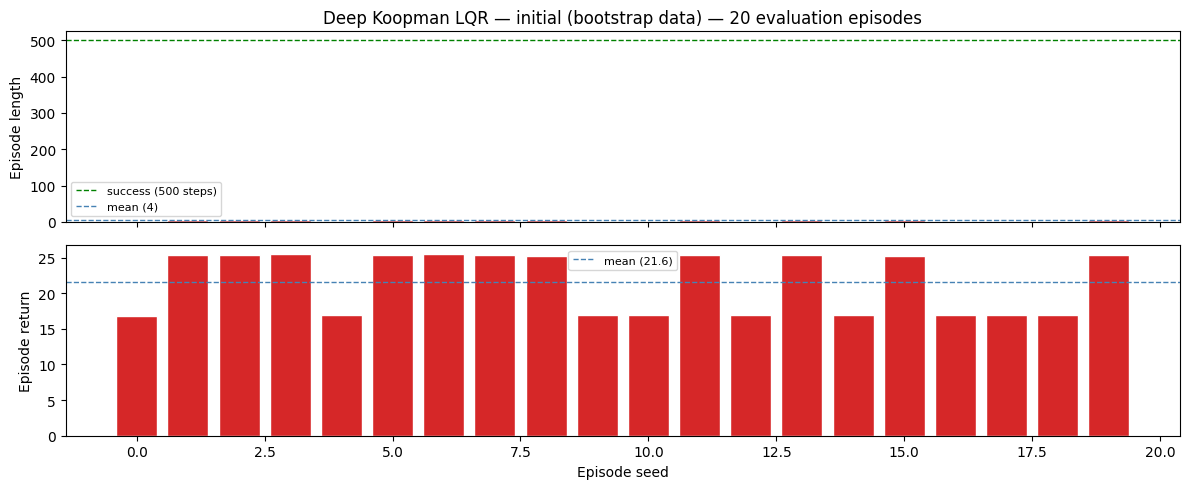

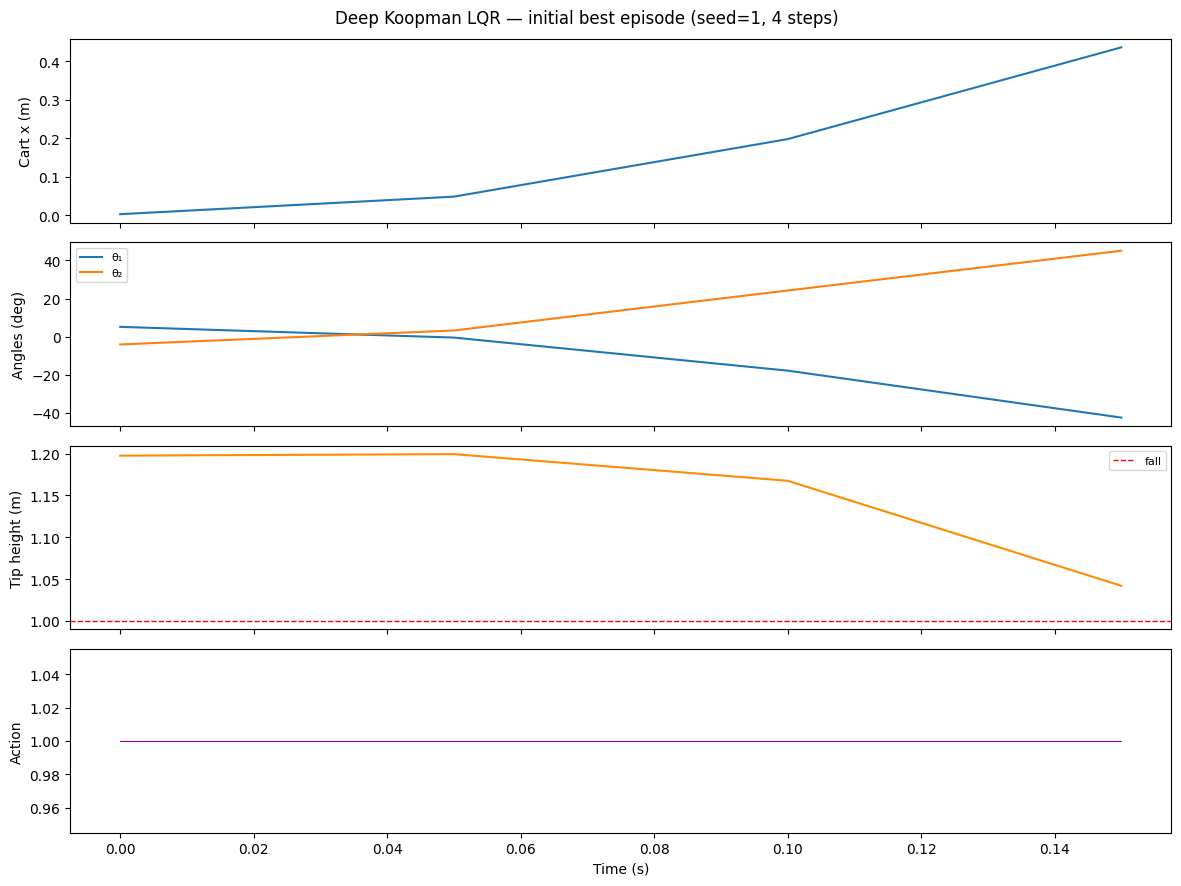

In [10]:
def eval_lqr(model, lqr, n_eval=N_EVAL, label="LQR"):
    """
    Evaluate LQR controller u = -K (phi(x) - z*) in real MuJoCo.
    Returns lengths, returns arrays and prints a summary row.
    """
    K, z_star = lqr["K"], lqr["z_star"]
    model.eval()
    env     = gym.make("InvertedDoublePendulum-v5")
    lengths, returns = [], []
    for seed in range(n_eval):
        obs, _ = env.reset(seed=seed)
        done   = False; ep_r = ep_l = 0
        while not done:
            x = obs_to_state6(obs)
            with torch.no_grad():
                z = model.encode(torch.tensor(x, dtype=torch.float32).unsqueeze(0)).squeeze().numpy()
            delta_z = z - z_star
            u = float(np.clip(-(K @ delta_z).item(), -1.0, 1.0))
            obs, r, term, trunc, _ = env.step(np.array([u], dtype=np.float32))
            done = term or trunc; ep_r += r; ep_l += 1
        lengths.append(ep_l); returns.append(ep_r)
    env.close()
    ll, lr = np.array(lengths), np.array(returns)
    suc = float(np.mean(ll >= CONV_SUCCESS))
    print(f"  {label:<36}  mean_len={ll.mean():6.0f}  mean_ret={lr.mean():8.1f}  success={suc:.0%}")
    return ll, lr


def plot_eval(lengths, returns, label="LQR"):
    """Bar chart + best-episode 4-panel trajectory."""
    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    colors = ["#2ca02c" if l >= CONV_SUCCESS else "#d62728" for l in lengths]
    axes[0].bar(range(N_EVAL), lengths, color=colors, edgecolor="white")
    axes[0].axhline(CONV_SUCCESS, color="green", ls="--", lw=1,
                    label=f"success ({CONV_SUCCESS} steps)")
    axes[0].axhline(lengths.mean(), color="steelblue", ls="--", lw=1,
                    label=f"mean ({lengths.mean():.0f})")
    axes[0].set_ylabel("Episode length"); axes[0].set_title(f"{label} — 20 evaluation episodes")
    axes[0].legend(fontsize=8)
    axes[1].bar(range(N_EVAL), returns, color=colors, edgecolor="white")
    axes[1].axhline(returns.mean(), color="steelblue", ls="--", lw=1,
                    label=f"mean ({returns.mean():.1f})")
    axes[1].set_ylabel("Episode return"); axes[1].set_xlabel("Episode seed")
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    return fig


def plot_best_episode(model, lqr, lengths, label="LQR"):
    """4-panel trajectory of the best episode."""
    K, z_star   = lqr["K"], lqr["z_star"]
    best_seed   = int(np.argmax(lengths))
    env         = gym.make("InvertedDoublePendulum-v5")
    obs, _      = env.reset(seed=best_seed)
    states, actions, heights = [], [], []
    done = False
    while not done:
        x = obs_to_state6(obs)
        with torch.no_grad():
            z = model.encode(torch.tensor(x, dtype=torch.float32).unsqueeze(0)).squeeze().numpy()
        u = float(np.clip(-(K @ (z - z_star)).item(), -1.0, 1.0))
        states.append(x); actions.append(u); heights.append(tip_height(x))
        obs, _, term, trunc, _ = env.step(np.array([u], dtype=np.float32))
        done = term or trunc
    env.close()
    states = np.array(states); t = np.arange(len(states)) * DT
    fig, ax4 = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
    ax4[0].plot(t, states[:, 0]); ax4[0].set_ylabel("Cart x (m)")
    ax4[1].plot(t, np.degrees(states[:, 1]), label="θ₁")
    ax4[1].plot(t, np.degrees(states[:, 2]), label="θ₂")
    ax4[1].set_ylabel("Angles (deg)"); ax4[1].legend(fontsize=8)
    ax4[2].plot(t, heights, color="darkorange")
    ax4[2].axhline(1.0, color="red", ls="--", lw=1, label="fall")
    ax4[2].set_ylabel("Tip height (m)"); ax4[2].legend(fontsize=8)
    ax4[3].plot(t, actions, color="purple", lw=0.8)
    ax4[3].set_ylabel("Action"); ax4[3].set_xlabel("Time (s)")
    fig.suptitle(f"{label} best episode (seed={best_seed}, {len(states)} steps)")
    plt.tight_layout()
    return fig


# ── Initial evaluation (bootstrap data only, no iterations yet) ───────────────
if lqr0 is not None:
    print("Initial LQR evaluation (bootstrap data only):")
    l0, r0 = eval_lqr(model, lqr0, label="Deep Koopman LQR (initial)")
    fig = plot_eval(l0, r0, label="Deep Koopman LQR — initial (bootstrap data)")
    plt.savefig(MODEL_DIR / "koopman_lqr_initial_eval.png", dpi=150); plt.show()
    fig = plot_best_episode(model, lqr0, l0, label="Deep Koopman LQR — initial")
    plt.savefig(MODEL_DIR / "koopman_lqr_initial_traj.png", dpi=150); plt.show()
else:
    print("Skipping eval — DARE did not converge on initial model.")
    l0, r0 = np.zeros(N_EVAL), np.zeros(N_EVAL)

## §4  Iterative Data Collection

The bootstrap dataset is biased toward falling-state transitions (the probe policy
explores broadly, not near upright). The initial LQR gain is therefore computed
from a model that has never seen the balance regime.

We fix this with a simple iterate-and-improve loop:

$$\text{for } t = 1, \dots, N_\text{iter}:$$

| Step | Action | Why |
|------|--------|-----|
| **[A] Fine-tune** | Train encoder on all data collected so far | More near-upright data → better encoder in balance regime |
| **[B] DARE** | Recompute $z^*$, $J_\psi$, $Q_\ell$, solve DARE → gain $K_t$ | Encoder has changed; LQR gain must be recomputed |
| **[C] Collect** | Deploy $u = -K_t(\varphi(x) - z^*)$ in real MuJoCo, record transitions | Policy explores near-upright if LQR is even partially effective |
| **[D] Evaluate** | 20 fixed seeds → mean\_len, success rate | Track convergence |

**Key difference from `sindy-rl.ipynb`**: steps C and D run in the **real environment**
only — there are no surrogate rollouts at any point, so surrogate exploitation
is structurally impossible regardless of model accuracy.

In [11]:
N_ITER_LOOP  = 5
N_COLLECT    = 2_000
N_FINETUNE   = 150

# Accumulate all data starting from bootstrap training set
X_data  = X_tr.copy()
U_data  = U_tr.copy()
Xn_data = Xn_tr.copy()

iter_history = []
lqr_current  = lqr0   # carry forward from §3

print(f"Iterative loop: {N_ITER_LOOP} iterations, {N_COLLECT:,} transitions per iter")
print("=" * 60)

for it in range(1, N_ITER_LOOP + 1):
    print(f"\n── Iteration {it} {'─'*46}")

    # [A] Fine-tune encoder on all data accumulated so far
    print(f"  [A] Fine-tuning on {len(X_data):,} transitions for {N_FINETUNE} epochs ...")
    train_koopman(model, X_data, U_data, Xn_data,
                  n_epochs=N_FINETUNE, lr=3e-4, verbose=False)

    # [B] Re-solve DARE with updated encoder
    try:
        lqr_current = design_lqr(model)
        print(f"  [B] DARE  sr_ol={lqr_current['sr_ol']:.3f}  "
              f"sr_cl={lqr_current['sr_cl']:.3f}  "
              f"unstable={lqr_current['n_unstable']}")
    except (LinAlgError, Exception) as e:
        print(f"  [B] DARE failed: {e} — keeping previous gain")

    # [C] Collect real transitions under current LQR policy
    K_c, z_star_c = lqr_current["K"], lqr_current["z_star"]
    env_col = gym.make("InvertedDoublePendulum-v5")
    X_new, U_new, Xn_new, col_lens = [], [], [], []
    rng_col = np.random.default_rng(20_000 + it * 7_919)

    while len(X_new) < N_COLLECT:
        obs, _ = env_col.reset(seed=int(rng_col.integers(0, 2**31)))
        done = False; ep_l = 0
        while not done:
            x = obs_to_state6(obs)
            with torch.no_grad():
                z = model.encode(
                    torch.tensor(x, dtype=torch.float32).unsqueeze(0)
                ).squeeze().numpy()
            u = float(np.clip(-(K_c @ (z - z_star_c)).item(), -1.0, 1.0))
            nobs, _, term, trunc, _ = env_col.step(np.array([u], dtype=np.float32))
            ns = obs_to_state6(nobs)
            if np.all(np.isfinite(ns)):
                X_new.append(x); U_new.append([u]); Xn_new.append(ns)
            obs = nobs; done = term or trunc; ep_l += 1
        col_lens.append(ep_l)
    env_col.close()

    X_data  = np.vstack([X_data,  X_new])
    U_data  = np.vstack([U_data,  U_new])
    Xn_data = np.vstack([Xn_data, Xn_new])
    print(f"  [C] Collected {len(X_new):,} transitions  "
          f"(mean ep len = {np.mean(col_lens):.0f} steps, "
          f"total data = {len(X_data):,})")

    # [D] Evaluate in real MuJoCo (20 fixed seeds)
    ll, lr = eval_lqr(model, lqr_current,
                      label=f"Deep Koopman LQR iter {it}")

    iter_history.append({
        "iter":    it,
        "n_data":  len(X_data),
        "sr_ol":   lqr_current["sr_ol"],
        "sr_cl":   lqr_current["sr_cl"],
        "mean_len": float(ll.mean()),
        "mean_ret": float(lr.mean()),
        "success":  float(np.mean(ll >= CONV_SUCCESS)),
        "lengths":  ll,
        "returns":  lr,
        "lqr":      lqr_current,
    })

best_iter = max(iter_history, key=lambda d: d["mean_len"])
print(f"\nBest iteration: {best_iter['iter']}  "
      f"mean_len={best_iter['mean_len']:.0f}  "
      f"success={best_iter['success']:.0%}")

Iterative loop: 5 iterations, 2,000 transitions per iter

── Iteration 1 ──────────────────────────────────────────────
  [A] Fine-tuning on 2,318 transitions for 150 epochs ...
  [B] DARE  sr_ol=1.291  sr_cl=1.055  unstable=1
  [C] Collected 2,001 transitions  (mean ep len = 5 steps, total data = 4,319)
  Deep Koopman LQR iter 1               mean_len=     5  mean_ret=    31.6  success=0%

── Iteration 2 ──────────────────────────────────────────────
  [A] Fine-tuning on 4,319 transitions for 150 epochs ...
  [B] DARE  sr_ol=1.327  sr_cl=0.994  unstable=0
  [C] Collected 2,001 transitions  (mean ep len = 4 steps, total data = 6,320)
  Deep Koopman LQR iter 2               mean_len=     4  mean_ret=    21.1  success=0%

── Iteration 3 ──────────────────────────────────────────────
  [A] Fine-tuning on 6,320 transitions for 150 epochs ...
  [B] DARE  sr_ol=1.549  sr_cl=0.996  unstable=0
  [C] Collected 2,002 transitions  (mean ep len = 4 steps, total data = 8,322)
  Deep Koopman LQR ite

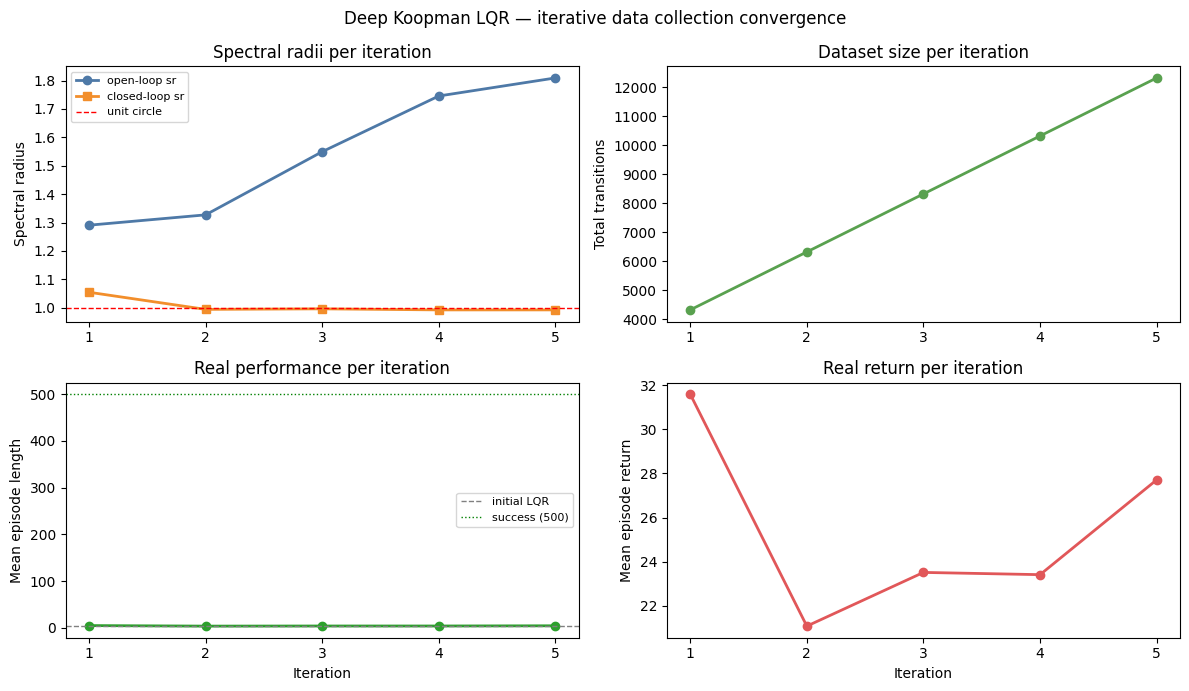


Final evaluation — best iteration (1):


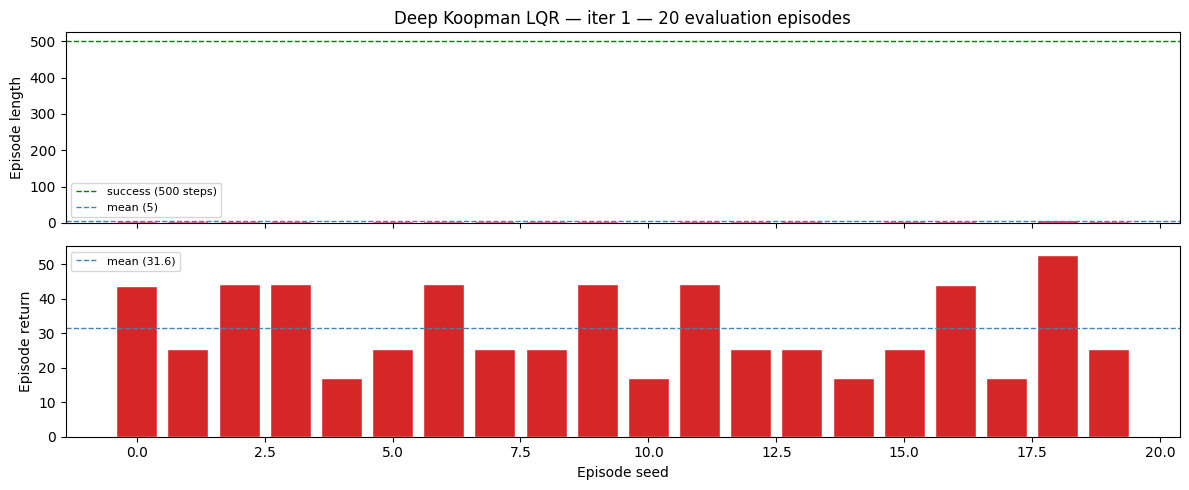

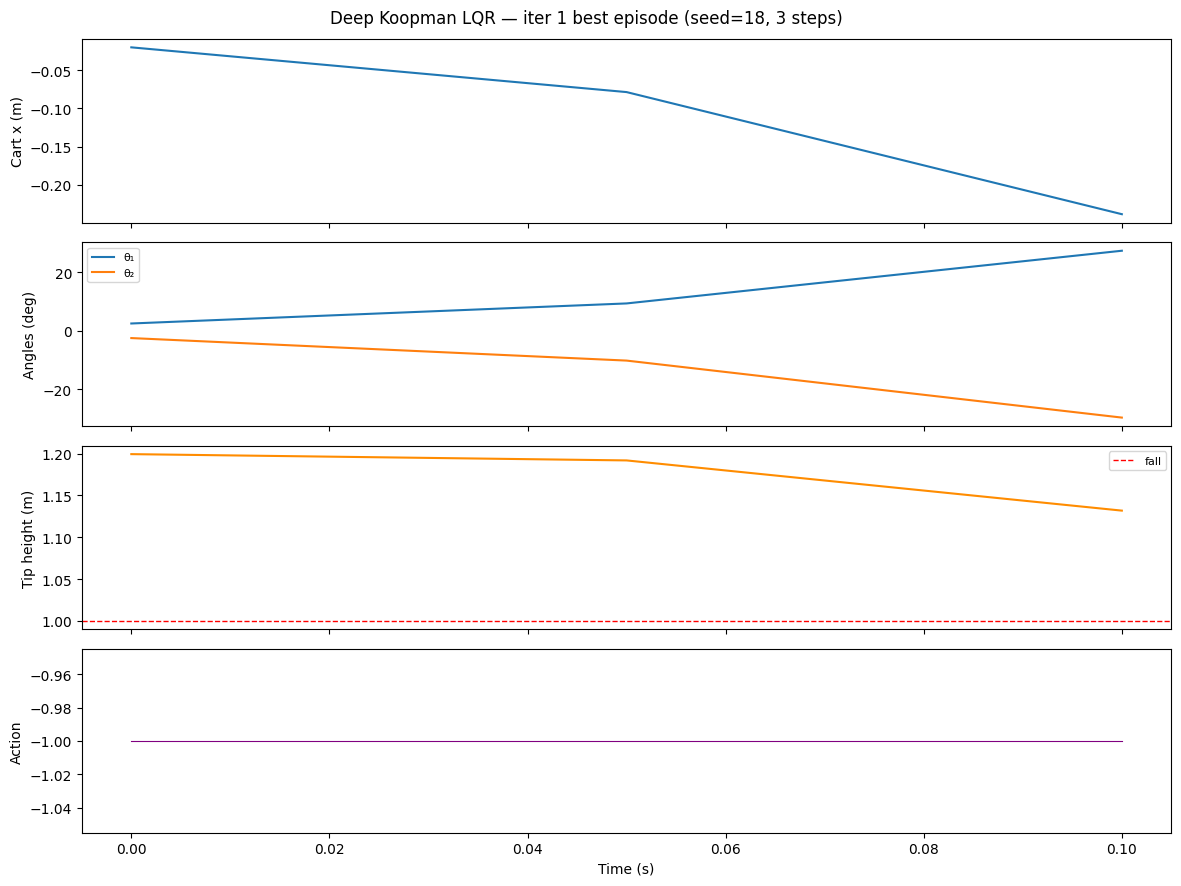

In [12]:
iters    = [d["iter"]     for d in iter_history]
sr_ol_v  = [d["sr_ol"]   for d in iter_history]
sr_cl_v  = [d["sr_cl"]   for d in iter_history]
len_v    = [d["mean_len"] for d in iter_history]
ret_v    = [d["mean_ret"] for d in iter_history]
n_data_v = [d["n_data"]   for d in iter_history]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

axes[0, 0].plot(iters, sr_ol_v, "o-", lw=2, color="#4e79a7", label="open-loop sr")
axes[0, 0].plot(iters, sr_cl_v, "s-", lw=2, color="#f28e2b", label="closed-loop sr")
axes[0, 0].axhline(1.0, color="red", ls="--", lw=1, label="unit circle")
axes[0, 0].set_ylabel("Spectral radius"); axes[0, 0].set_title("Spectral radii per iteration")
axes[0, 0].legend(fontsize=8); axes[0, 0].set_xticks(iters)

axes[0, 1].plot(iters, n_data_v, "o-", lw=2, color="#59a14f")
axes[0, 1].set_ylabel("Total transitions"); axes[0, 1].set_title("Dataset size per iteration")
axes[0, 1].set_xticks(iters)

axes[1, 0].plot(iters, len_v, "o-", lw=2, color="#2ca02c")
if lqr0 is not None:
    axes[1, 0].axhline(l0.mean(), color="gray", ls="--", lw=1, label="initial LQR")
axes[1, 0].axhline(CONV_SUCCESS, color="green", ls=":", lw=1, label=f"success ({CONV_SUCCESS})")
axes[1, 0].set_ylabel("Mean episode length"); axes[1, 0].set_title("Real performance per iteration")
axes[1, 0].legend(fontsize=8); axes[1, 0].set_xticks(iters); axes[1, 0].set_xlabel("Iteration")

axes[1, 1].plot(iters, ret_v, "o-", lw=2, color="#e15759")
axes[1, 1].set_ylabel("Mean episode return"); axes[1, 1].set_title("Real return per iteration")
axes[1, 1].set_xticks(iters); axes[1, 1].set_xlabel("Iteration")

fig.suptitle("Deep Koopman LQR — iterative data collection convergence")
plt.tight_layout()
plt.savefig(MODEL_DIR / "koopman_convergence.png", dpi=150)
plt.show()

# ── Best iteration: full evaluation + trajectory ──────────────────────────────
print(f"\nFinal evaluation — best iteration ({best_iter['iter']}):")
fig = plot_eval(best_iter["lengths"], best_iter["returns"],
                label=f"Deep Koopman LQR — iter {best_iter['iter']}")
plt.savefig(MODEL_DIR / "koopman_lqr_best_eval.png", dpi=150); plt.show()
fig = plot_best_episode(model, best_iter["lqr"], best_iter["lengths"],
                        label=f"Deep Koopman LQR — iter {best_iter['iter']}")
plt.savefig(MODEL_DIR / "koopman_lqr_best_traj.png", dpi=150); plt.show()

## §5  Comparison vs Dyna-SINDy-RL

We compare the best Deep Koopman LQR iteration against the Dyna-SINDy-RL
baseline from `sindy-rl.ipynb` §5 (Dyna iter 6, same 20 evaluation seeds).

### What a performance difference tells us

| Outcome | Interpretation |
|---------|---------------|
| Koopman ≈ SINDy-RL | LQR in learned Koopman space is competitive with PPO in SINDy surrogate |
| Koopman < SINDy-RL | The balance task requires richer exploration than LQR provides; RL's trial-and-error finds policies LQR cannot |
| Koopman > SINDy-RL | Eliminating surrogate exploitation and using an optimal (DARE) controller outweighs SINDy's superior nonlinear model |

The two approaches are fundamentally different in *what they optimise*: LQR minimises
a quadratic cost with respect to the learned linear model, while PPO maximises expected
return through stochastic search.  Neither dominates in general; the result here
is specific to this system and these hyperparameters.

  Method                                  mean_len    mean_ret  success
  ----------------------------------------------------------------------
  Dyna-SINDy-RL (sindy-rl.ipynb §5)            854      7988.6      85%
  Deep Koopman LQR (initial)                     4        21.6       0%
  Deep Koopman LQR (iter 1)                      5        31.6       0%
  Deep Koopman LQR (iter 2)                      4        21.1       0%
  Deep Koopman LQR (iter 3)                      4        23.5       0%
  Deep Koopman LQR (iter 4)                      4        23.4       0%
  Deep Koopman LQR (iter 5)                      4        27.7       0%


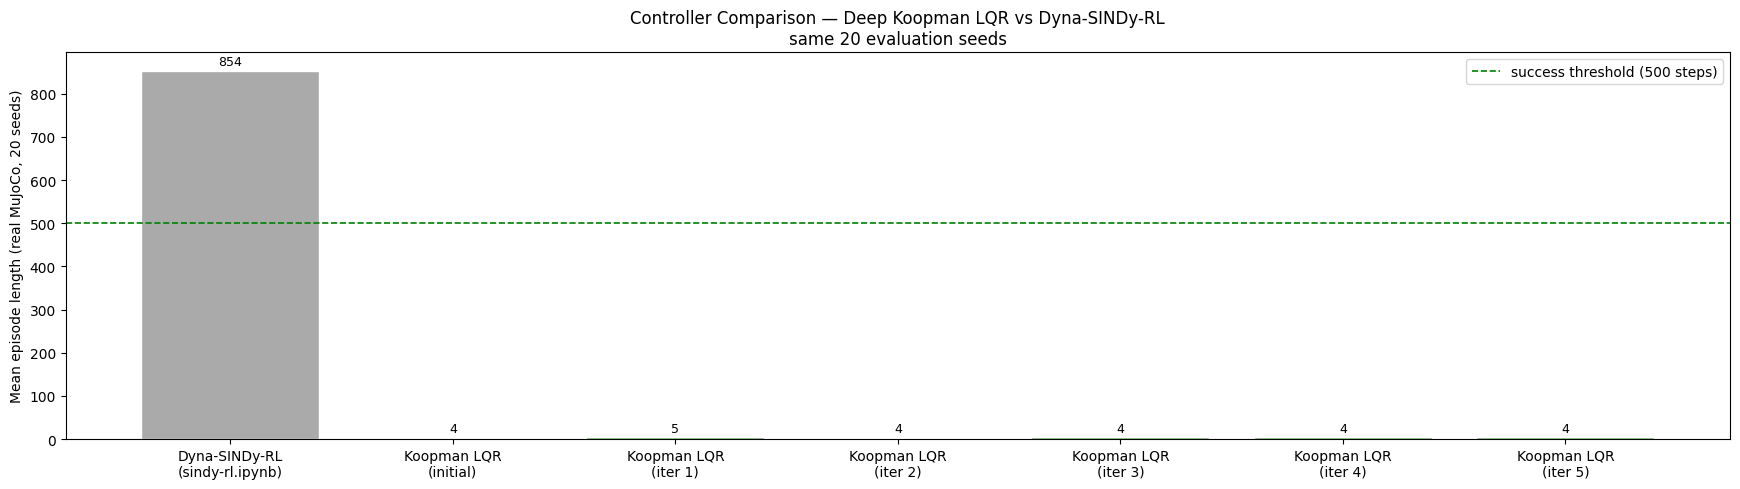

In [13]:
# ── Summary table ─────────────────────────────────────────────────────────────
print(f"  {'Method':<38}  {'mean_len':>8}  {'mean_ret':>10}  {'success':>7}")
print("  " + "-" * 70)
print(f"  {'Dyna-SINDy-RL (sindy-rl.ipynb §5)':<38}  "
      f"{SINDY_RL_MEAN_LEN:>8.0f}  {SINDY_RL_MEAN_RET:>10.1f}  {SINDY_RL_SUCCESS:>7.0%}")

if lqr0 is not None:
    def _row(name, ll, lr):
        suc = float(np.mean(ll >= CONV_SUCCESS))
        print(f"  {name:<38}  {ll.mean():>8.0f}  {lr.mean():>10.1f}  {suc:>7.0%}")
    _row("Deep Koopman LQR (initial)", l0, r0)
    for d in iter_history:
        _row(f"Deep Koopman LQR (iter {d['iter']})", d["lengths"], d["returns"])

# ── Bar chart ──────────────────────────────────────────────────────────────────
methods = ["Dyna-SINDy-RL\n(sindy-rl.ipynb)", "Koopman LQR\n(initial)"]
lens_bar = [SINDY_RL_MEAN_LEN, float(l0.mean()) if lqr0 is not None else 0.0]
colors_bar = ["#aaaaaa", "#4e79a7"]

for d in iter_history:
    methods.append(f"Koopman LQR\n(iter {d['iter']})")
    lens_bar.append(d["mean_len"])
    colors_bar.append("#59a14f")

fig, ax = plt.subplots(figsize=(max(8, 2.5 * len(methods)), 5))
bars = ax.bar(methods, lens_bar, color=colors_bar, edgecolor="white")
ax.axhline(CONV_SUCCESS, color="green", ls="--", lw=1.2,
           label=f"success threshold ({CONV_SUCCESS} steps)")
for bar, v in zip(bars, lens_bar):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f"{v:.0f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Mean episode length (real MuJoCo, 20 seeds)")
ax.set_title("Controller Comparison — Deep Koopman LQR vs Dyna-SINDy-RL\n"
             "same 20 evaluation seeds")
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / "koopman_final_comparison.png", dpi=150)
plt.show()